<a href="https://colab.research.google.com/github/luu-quang/Data_Mining_and_Machine_Learning_USTH/blob/Khanh/SVMClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.linear_model import SGDClassifier

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc #để xoá object khỏi ram khi không cần nữa

from google.colab import drive
#drive ngáo lắm phải forece_remount
drive.mount("/content/drive", force_remount=True)
import shutil
import os
import pyarrow.parquet as pq
import pyarrow as pa
import joblib
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import time
from sklearn.utils import resample

pd.set_option('display.max_columns', None)
if hasattr(pd, 'options'):
    pd.options.mode.copy_on_write = True  #chỉ tạo copy của dataframe khi có hành động write->kiểm soát số lượng copy

Mounted at /content/drive


In [4]:
cwd = '/content/drive/MyDrive/bank_data/'

In [26]:
start = time.time()
!cp -r /content/drive/MyDrive/bank_data/ /content/
print(time.time() - start)
cwd = '/content/bank_data/'

30.695096731185913


In [27]:
target = ["product_1","product_2",
              "product_3","product_4","product_5",
               "product_6","product_7","product_8","product_9","product_10","product_11",
               "product_12","product_13","product_14","product_15","product_16",
               "product_17","product_18","product_19","product_20","product_21",
               "product_22","product_23","product_24"]

In [28]:
customer_info_cols = ['customer_code', 'employee_index', 'customer_country', 'sex', 'age',
       'new_index', 'seniority_months', 'primary_customer', 'month_start_type',
       'relation_type', 'residence_index', 'foreigner_index', 'join_channel',
       'province_code', 'activity_index', 'gross_househole_income', 'segment']

In [29]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve, confusion_matrix, classification_report

binary_valid_parquet = cwd+"binary_valid.parquet"
binary_train_parquet = cwd+"binary_train.parquet"

df_train = pd.read_parquet(binary_train_parquet)
n_rows_merged = 183288456
n_1_merged = 309212
scale_pos_weight = (n_rows_merged - n_1_merged) / n_1_merged
scaling_cols = ['age', 'seniority_months', 'gross_househole_income']
nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']
nominal_categories = {}
ordinal_col = 'segment'
label_map = {'01 - TOP': 3, '02 - PARTICULARES': 2, '03 - UNIVERSITARIO': 1}
scaling_cols = ['age', 'seniority_months', 'gross_househole_income']
scaling_dict = {}
df_train['gross_househole_income'] = np.log1p(df_train['gross_househole_income'])
for col in scaling_cols:
  mean = df_train[col].mean()
  stddev = df_train[col].std()
  scaling_dict[col] = (mean, stddev)
cat_encoder = ColumnTransformer(
    transformers = [('categorical_encoder', OneHotEncoder(), nominal_cols)],
    remainder = 'passthrough'
)
cat_encoder.fit(df_train)
cat_prefix = 'categorical_encoder__'
non_cat_prefix = 'remainder__'
del df_train
gc.collect()

23

In [30]:
def generate_dtrain(binary_train_parquet):
  df_train = pd.read_parquet(binary_train_parquet)
  df_train['gross_househole_income'] = np.log1p(df_train['gross_househole_income'])
  df_train[ordinal_col] = df_train[ordinal_col].map(label_map)
  df_train[ordinal_col] = df_train[ordinal_col].fillna(df_train[ordinal_col].mode()[0]).astype(np.int8)
  for col in scaling_cols:
    df_train[col] = (df_train[col] - scaling_dict[col][0]) / scaling_dict[col][1]
  df_train = cat_encoder.transform(df_train)
  df_train = pd.DataFrame(data=df_train, columns=cat_encoder.get_feature_names_out())
  df_train.drop(columns=[non_cat_prefix+'customer_code'], inplace=True)
  X_train = df_train.drop(columns=[non_cat_prefix+'new_buy'])
  y_train = df_train[non_cat_prefix+'new_buy']
  del df_train
  gc.collect()
  return X_train, y_train

In [31]:
from sklearn.model_selection import StratifiedKFold
target_cols = [f'{product}_last_0' for product in target]
categorical_cols = ['employee_index', 'relation_type', 'segment']
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
int8_cols = ['age', 'activity_index', 'new_index']
int16_cols = ['seniority_months']
to_binary_cols = ['sex', 'primary_customer', 'residence_index', 'foreigner_index']
dtype_dict = {'customer_code': np.int32,
              'product': np.int8,
              'new_buy': np.int8,
              'month_start_type': 'string',
              **{col: 'category' for col in categorical_cols},
              **{col: np.float32 for col in high_cardinal_cols+['month_sin','month_cos']},
              **{col: np.int8 for col in int8_cols+to_binary_cols},
              'seniority_months': np.int16,
              **{f'product'+f'_last_{month}': np.int8 for month in list(range(6,0,-1))},
              **{f'product'+f'_diff_last_{month}': np.int8 for month in list(range(5,0,-1))}
              }
nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']

def generate_dval(val_parquet, n_splits, min_per_fold, dataset, batch_size=30000):
  if os.path.exists(dataset):
    shutil.rmtree(dataset)
  os.mkdir(dataset)
  df = pd.read_parquet(val_parquet)
  df['total_new_buy'] = df[target_cols].sum(axis=1)
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=None)
  fold = np.random.choice(range(0, n_splits))
  counts = df['total_new_buy'].value_counts()
  minimum = n_splits * min_per_fold
  minimum_list = []
  for total, n_customer in counts.items():
    if n_customer < minimum:
      minimum_list.append(df[df["total_new_buy"]==total].copy())
      df = df[df['total_new_buy'] != total]
  for i, (train_index, test_index) in enumerate(skf.split(df.drop(columns=['total_new_buy']), df['total_new_buy'])):
    if i != fold:
      continue
    df_fold = df.iloc[test_index]
    break
  df_fold.drop(columns=['total_new_buy'], inplace=True)
  del df
  gc.collect()
  n_row = len(df_fold)
  n_batch = n_row // batch_size + 1
  start = 0
  end = 0
  for batch in range(n_batch):
    df_list = []
    start += batch * batch_size
    end = start + batch_size
    if end >= n_row:
      end = n_row - 1
    df_batch = df_fold.iloc[start:end]
    for label, product in enumerate(target_cols):
      product_df = df_batch.copy()
      product_df['product'] = label+1
      product_df['new_buy'] = product_df[product]
      cols = (['customer_code', 'product', 'new_buy']+
              customer_info_cols[1:]+['month_sin', 'month_cos']+
              [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
              [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
      product_df = product_df[cols]
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
      df_list.append(product_df)
    df_product = pd.concat(df_list, ignore_index=True)
    table = pa.Table.from_pandas(df_product)
    for df in df_list:
      del df
      gc.collect()
    del df_batch, df_product
    gc.collect()
    pq.write_to_dataset(table, root_path=dataset)
    del table
    gc.collect()
  del df_fold
  gc.collect()
  df_val = pd.read_parquet(dataset)
  df_val = df_val.astype(dtype_dict)
  df_minimum = pd.concat(minimum_list, ignore_index=True)
  for df in minimum_list:
    del df
    gc.collect()
  for label, product in enumerate(target_cols):
    product_df = df_minimum.copy()
    product_df['product'] = label+1
    product_df['new_buy'] = product_df[product]
    cols = (['customer_code', 'product', 'new_buy']+
            customer_info_cols[1:]+['month_sin', 'month_cos']+
            [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
            [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
    product_df = product_df[cols]
    product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
    product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
    df_list.append(product_df)
  df_minimum = pd.concat(df_list, ignore_index=True)
  df_minimum = df_minimum.astype(dtype_dict)
  for df in df_list:
    del df
    gc.collect()
  df_val = pd.concat([df_val, df_minimum], ignore_index=True)
  df_val['gross_househole_income'] = np.log1p(df_val['gross_househole_income'])
  df_val[ordinal_col] = df_val[ordinal_col].map(label_map)
  df_val[ordinal_col] = df_val[ordinal_col].fillna(df_val[ordinal_col].mode()[0]).astype(np.int8)
  for col in scaling_cols:
    df_val[col] = (df_val[col] - scaling_dict[col][0]) / scaling_dict[col][1]
  df_val = cat_encoder.transform(df_val)
  df_val = pd.DataFrame(data=df_val, columns=cat_encoder.get_feature_names_out())
  X_val = df_val.drop(columns=[non_cat_prefix+'new_buy', non_cat_prefix+'customer_code'])
  y_val = df_val[non_cat_prefix+'new_buy']
  del df_val, df_list
  gc.collect()
  return X_val, y_val


In [32]:
def hard_negative_mining(labels, preds, hard_negative_set, n_hard_negative):
  df = pd.DataFrame({"label": labels, "pred": preds})
  df = df.sort_values("pred")
  hard_negative_idx = np.argsort(-df.loc[df['label']==0, 'pred'])[:n_hard_negative]
  for index in hard_negative_idx:
    start = (index // 24) * 24
    end = start + 24
    hard_negative_set.add(start)

def update_dval_dtrain(X_val, y_val, X_train, y_train, hard_negative_set):
  if len(hard_negative_set)==0:
    return X_val, y_val, X_train, y_train
  val_del_idx = []
  for start in hard_negative_set:
    val_del_idx.extend(list(range(start, start+24)))
  n_rows_val = len(X_val)
  X_train_add = X_val.iloc[val_del_idx]
  y_train_add = y_val.iloc[val_del_idx]
  idx_to_keep = [i for i in range(n_rows_val) if i not in val_del_idx]
  X_val_mined = X_val.drop(index=idx_to_keep)
  X_val_mined = X_val_mined.reset_index(drop=True)
  y_val_mined = y_val.drop(index=idx_to_keep)
  y_val_mined = y_val_mined.reset_index(drop=True)
  X_train = pd.concat([X_train, X_train_add], ignore_index=True)
  y_train = pd.concat([y_train, y_train_add], ignore_index=True)
  del X_train_add, y_train_add
  gc.collect()
  return X_val_mined, y_val_mined, X_train, y_train

In [33]:
best_score = -np.inf
best_params = None
best_sgd_path1 = "/content/drive/My Drive/bank_data/best_sgd1.pkl"
best_sgd_path2 = "/content/drive/My Drive/bank_data/best_sgd2.pkl"
best_sgd_path3 = "/content/drive/My Drive/bank_data/best_sgd3.pkl"
best_best_sgd_path = "/content/drive/My Drive/bank_data/best_best_sgd.pkl"
best_model_dict = {}
for path in [best_sgd_path1, best_sgd_path2, best_sgd_path3]:
  best_model_dict[path] = 0.0

In [34]:
for path in [best_sgd_path1, best_sgd_path2, best_sgd_path3]:
  if os.path.exists(path):
      os.remove(path)

In [35]:
def model_tier(model, metric, best_model_dict):
  items = list(best_model_dict.items())
  candidate = (model, metric)
  for tier, (path, best_metric) in enumerate(items):
    if candidate[1] < best_metric:
      continue
    else:
      old_model = joblib.load(path) if os.path.exists(path) else None
      old_metric = best_model_dict[path]
      tmp_path = path+'.tmp'
      joblib.dump(candidate[0], tmp_path)
      os.replace(tmp_path, path)
      del candidate[0]
      gc.collect()
      best_model_dict[path] = candidate[1]
      candidate = (old_model, old_metric)
      if candidate[0] is None:
        break


In [36]:
sgd = joblib.load(best_sgd_path)
joblib.dump(sgd, best_best_sgd_path)

NameError: name 'best_sgd_path' is not defined

In [36]:
params = {
    'penalty': 'l2',
    'alpha': 1e-4,
    'l1_ratio': 0.15,
    'tol': 1e-3,
    'learning_rate': 'optimal',
    'eta0': 0.01,
    'power_t': 0.5,

    'loss': 'hinge',
    'n_jobs': -1,
    'random_state': 42,
    'early_stopping': True,
    'class_weight': {0: 1,1: scale_pos_weight},
    'n_iter_no_change': 5,
    'validation_fraction': 0.1,
    'warm_start': True,
    'max_iter': 200
}

param_grid = {
    'penalty': ['l1','l2','elasticnet'],
    'alpha': list(np.round(np.geomspace(1e-4,1e-1, 20),5))+list(np.round(np.linspace(1e-4,1e-1, 20),5)),
    'l1_ratio': np.round(np.arange(0.01,1.0,0.05), 2),
    'tol': list(np.round(np.geomspace(1e-4,1e-2, 20),4))+list(np.round(np.linspace(1e-4,1e-2, 20),4)),
    'learning_rate': ['constant', 'optimal', 'invscaling', "adaptive", "pa1", "pa2"],
    'eta0': list(np.round(np.geomspace(1e-3,1e-1, 20),3))+list(np.round(np.linspace(1e-3,1e-1, 20),3)),
    'power_t': np.round(np.linspace(1e-1,2,30),2),
    'validation_fraction': np.round(np.linspace(0.05,0.15,20),2),
    'n_iter_no_change': np.arange(5,11,1),
    'max_iter': np.arange(100, 300, 20)
}

def custom_auc_pr(preds, labels):
  idx_list = []
  for i in range(len(preds)):
    start = i*24
    end = start+24
    customer_probs = preds[start:end]
    top_5_probs_idx = np.argsort(-customer_probs)[:6]
    top_5_probs_idx = top_5_probs_idx + start
    idx_list.extend(top_5_probs_idx)
  labels_top = labels[idx_list]
  preds_top = preds[idx_list]
  return 'val_auc_pr', average_precision_score(labels, preds)

class CustomeEvaluator:
  def __init__(self, hard_negative_set, n_hard_negative):
    self.hard_negative_set = hard_negative_set
    self.n_hard_negative = n_hard_negative
  def custom_auc_pr(self, preds, labels):
    hard_negative_mining(labels, preds, self.hard_negative_set, self.n_hard_negative)
    return custom_auc_pr(preds, labels)

valid_parquet = cwd+"merged_valid_dataset/chunk_10.parquet"
dval_dataset = cwd+"dval_dataset/"
n_rounds_between_mining = 200
n_rounds_total = 2000
n_hard_negative = 100

for i in range(100):
  print(f'{i+1}th Model')
  params_trial = params.copy()
  for param in param_grid.keys():
    params_trial[param] = np.random.choice(param_grid[param])
  print(params_trial)
  n_rounds_between_mining = params_trial['max_iter']
  X_train, y_train = generate_dtrain(binary_train_parquet)
  print(X_train.shape)
  time.sleep(5)
  X_val, y_val = generate_dval(valid_parquet, 50, 20, dval_dataset)
  print(X_val.shape)
  early_stopping_val = 0
  last_val_score = 0
  for j in range(n_rounds_total // n_rounds_between_mining):
    hard_negative_set = set()
    sgd = SGDClassifier(
        loss=params_trial['loss'],
        penalty=params_trial['penalty'],
        alpha=params_trial['alpha'],
        l1_ratio=params_trial['l1_ratio'],
        tol=params_trial['tol'],
        learning_rate=params_trial['learning_rate'],
        eta0=params_trial['eta0'],
        power_t=params_trial['power_t'],
        n_jobs=params_trial['n_jobs'],
        random_state=params_trial['random_state'],
        early_stopping=params_trial['early_stopping'],
        class_weight=params_trial['class_weight'],
        warm_start = params_trial['warm_start'],
        max_iter=params_trial['max_iter']
    )

    evaluator = CustomeEvaluator(hard_negative_set, n_hard_negative)
    try:
      sgd.fit(X_train, y_train)
    except ValueError as e:
      if "under-/overflow" in str(e):
        print("Skipped overflow config")
        break
      else:
        raise
    val_eval = evaluator.custom_auc_pr(sgd.decision_function(X_val), y_val)
    print("Number of hard negatives:", len(hard_negative_set))
    print(f'{val_eval[0]}: {val_eval[1]}')
    if val_eval[1] <= last_val_score:
      early_stopping_val += 1
    else:
      last_val_score = val_eval[1]
      early_stopping_val = 0
      model_tier(sgd, val_eval[1]-0.02*(j), best_model_dict)
    if early_stopping_val >=5:
      print("No improvement after 5 rounds! Continue to next param_set")
      break
    print(f"Done a {n_rounds_between_mining}-rounds loop")
    X_val, y_val, X_train, y_train = update_dval_dtrain(X_val, y_val, X_train, y_train, hard_negative_set)
    gc.collect()
  print(best_model_dict)
print(f"Best AUC: {best_score:.4f}")
print(f"Best params: {best_params}")


1th Model
{'penalty': np.str_('elasticnet'), 'alpha': np.float64(0.06319), 'l1_ratio': np.float64(0.41), 'tol': np.float64(0.0079), 'learning_rate': np.str_('optimal'), 'eta0': np.float64(0.1), 'power_t': np.float64(0.1), 'loss': 'hinge', 'n_jobs': -1, 'random_state': 42, 'early_stopping': True, 'class_weight': {0: 1, 1: 591.7598411445869}, 'n_iter_no_change': np.int64(5), 'validation_fraction': np.float64(0.11), 'warm_start': True, 'max_iter': np.int64(220)}
(3440182, 64)
(905472, 64)
Number of hard negatives: 7
val_auc_pr: 0.0023002450152839957


TypeError: 'tuple' object doesn't support item deletion

In [16]:
%whos
del X_train, y_train, sgd
gc.collect()
%whos

Variable                  Type                 Data/Info
--------------------------------------------------------
ColumnTransformer         ABCMeta              <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
CustomeEvaluator          type                 <class '__main__.CustomeEvaluator'>
OneHotEncoder             type                 <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
SGDClassifier             ABCMeta              <class 'sklearn.linear_mo<...>_gradient.SGDClassifier'>
StandardScaler            type                 <class 'sklearn.preproces<...>ng._data.StandardScaler'>
StratifiedKFold           ABCMeta              <class 'sklearn.model_sel<...>._split.StratifiedKFold'>
X_train                   DataFrame                     categorical_enco<...>440422 rows x 64 columns]
X_val                     DataFrame                 categorical_encoder_<...>\n[120 rows x 64 columns]
average_precision_score   function             <function average_precisi<...>_scor

NameError: name 'sgd' is not defined

In [14]:
print(f"Best AUC: {best_score:.4f}")
print(f"Best params: {best_params}")

Best AUC: 0.6341
Best params: {'penalty': np.str_('elasticnet'), 'alpha': np.float64(0.00298), 'l1_ratio': np.float64(0.76), 'tol': np.float64(0.0007), 'learning_rate': np.str_('constant'), 'eta0': np.float64(0.006), 'power_t': np.float64(1.61), 'loss': 'hinge', 'n_jobs': -1, 'random_state': 42, 'early_stopping': True, 'class_weight': {0: 1, 1: 591.7598411445869}, 'n_iter_no_change': np.int64(9), 'validation_fraction': np.float64(0.09), 'warm_start': True, 'max_iter': np.int64(100)}


In [53]:
import os
y_pred = []
y_val = []
best_best_sgd_path = "/content/drive/My Drive/bank_data/best_best_sgd.pkl"
best_model = joblib.load(best_best_sgd_path)
binary_valid_dataset = '/content/drive/My Drive/bank_data/binary_valid_dataset/file_1/'
for filepath in os.listdir(binary_valid_dataset):
  X_vals, y_vals = generate_dtrain(binary_valid_dataset+filepath)
  y_preds = best_model.decision_function(X_vals)
  y_pred.extend(y_preds)
  y_val.extend(y_vals)
  del X_vals


In [64]:
y_pred = np.array(y_pred)
y_val = np.array(y_val)

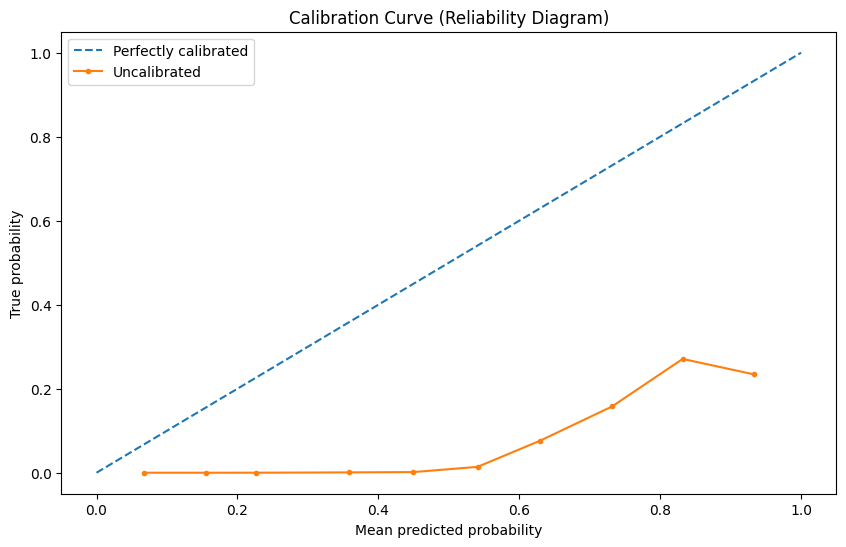

In [55]:
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

def compute_scores(y_true, y_pred_proba, name=None):
    """Compute a specific set of classification scores."""
    scores = {
        'brier_score': brier_score_loss(y_true, y_pred_proba),
        'log_loss_score': log_loss(y_true, y_pred_proba),
        'roc_auc': roc_auc_score(y_true, y_pred_proba)
    }
    return pd.Series(scores).rename(name)

y_pred_proba = (y_pred - y_pred.min()) / (y_pred.max()-y_pred.min())
prob_true, prob_pred = calibration_curve(y_val, y_pred_proba, n_bins=10)
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.plot(prob_pred, prob_true, marker='.', label='Uncalibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('True probability')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.show()

In [56]:
print(compute_scores(y_val, y_pred_proba, name='Uncalibrated'))


brier_score       0.103206
log_loss_score    0.365088
roc_auc           0.916581
Name: Uncalibrated, dtype: float64


In [57]:
clf_platt = CalibratedClassifierCV(best_model, cv=5, method='sigmoid')
clf_isotonic = CalibratedClassifierCV(best_model, cv=5, method='isotonic')
X_train, y_train = generate_dtrain(binary_train_parquet)
clf_platt.fit(X_train, y_train)
clf_isotonic.fit(X_train, y_train)
del X_train, y_train


179

In [61]:
binary_valid_dataset = '/content/drive/My Drive/bank_data/binary_valid_dataset/file_1/'
y_val = []
y_pred_proba_platt = []
y_pred_proba_isotonic = []
for filepath in os.listdir(binary_valid_dataset):
  X_vals, y_vals = generate_dtrain(binary_valid_dataset+filepath)
  y_pred_proba_platt.extend(clf_platt.predict_proba(X_vals)[:, 1])
  y_pred_proba_isotonic.extend(clf_isotonic.predict_proba(X_vals)[:, 1])
  y_val.extend(y_vals)
  del X_vals

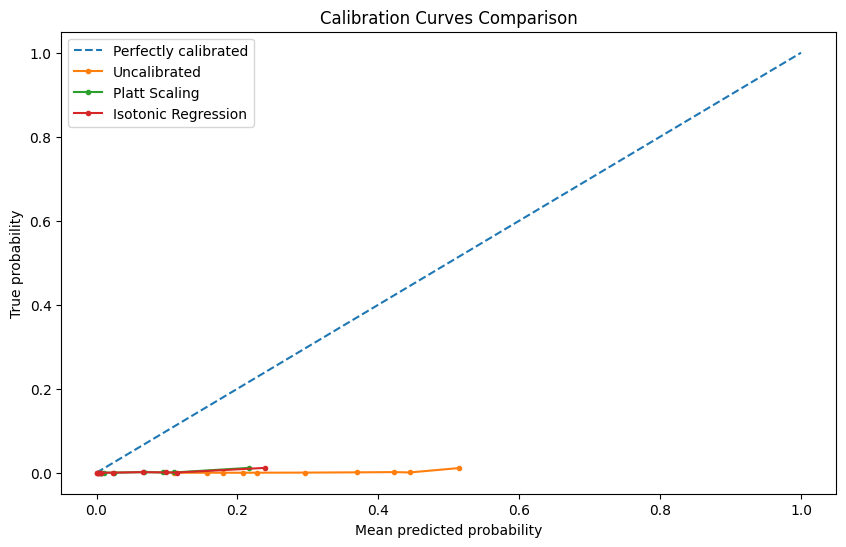

In [62]:
prob_true, prob_pred_uncal = calibration_curve(
    y_val, y_pred_proba, n_bins=10, strategy='quantile'
)
prob_true_platt, prob_pred_platt = calibration_curve(
    y_val, y_pred_proba_platt, n_bins=10, strategy='quantile'
)
prob_true_isotonic, prob_pred_isotonic = calibration_curve(
    y_val, y_pred_proba_isotonic, n_bins=10, strategy='quantile'
)
# Calibration plot
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.plot(prob_pred_uncal, prob_true, marker='.', label='Uncalibrated')
plt.plot(prob_pred_platt, prob_true_platt, marker='.', label='Platt Scaling')
plt.plot(prob_pred_isotonic, prob_true_isotonic, marker='.', label='Isotonic Regression')
plt.xlabel('Mean predicted probability')
plt.ylabel('True probability')
plt.title('Calibration Curves Comparison')
plt.legend()
plt.show()

In [63]:
y_pred = y_pred_proba_platt

In [65]:
print(len(y_pred))
print(y_val.sum())
n_customer = len(y_pred) / 24
idx_list = []
for i in range(int(n_customer)):
  start = i*24
  end = start+24
  customer_probs = y_pred[start:end]
  top_probs_idx = np.argsort(-customer_probs)[:3]
  top_probs_idx = top_probs_idx + start
  idx_list.extend(top_probs_idx)
y_val_top = y_val[idx_list]
y_pred_top = y_pred[idx_list]

22260984
31952.0


In [66]:
print(len(y_val_top))
print(len(y_pred_top))
print(y_val_top.sum() / y_val.sum())

2782623
2782623
0.7418314972458688


Test data performance:
AUC-ROC: 0.8560
AUC-PR: 0.0863


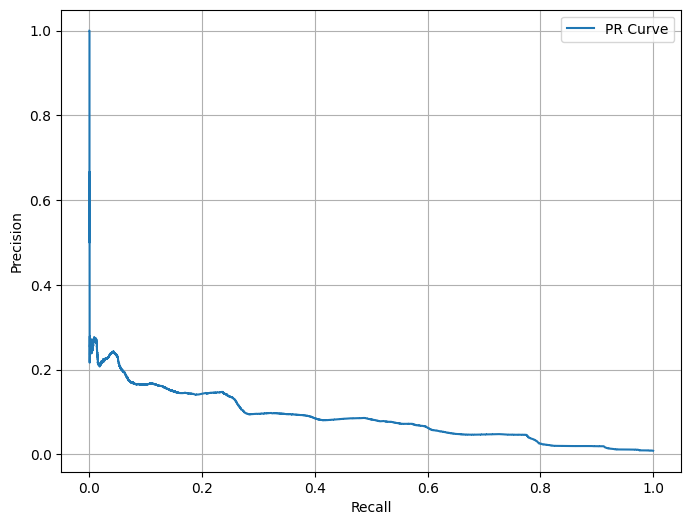

In [19]:
auc_roc = roc_auc_score(y_val_top, y_pred_top)
auc_pr = average_precision_score(y_val_top, y_pred_top)
print(f"Test data performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_val_top, y_pred_top)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='PR Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [20]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

31.103608518054667


In [21]:
threshold = optimal_threshold
y_pred_top_binary = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top_binary))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99   2759554
         1.0       0.15      0.24      0.18     23069

    accuracy                           0.98   2782623
   macro avg       0.57      0.61      0.59   2782623
weighted avg       0.99      0.98      0.98   2782623



In [23]:
threshold = 0.995
y_pred_top_binary = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top_binary))

              precision    recall  f1-score   support

         0.0       1.00      0.00      0.00   2759554
         1.0       0.01      1.00      0.02     23069

    accuracy                           0.01   2782623
   macro avg       0.50      0.50      0.01   2782623
weighted avg       0.99      0.01      0.00   2782623



In [22]:
print(confusion_matrix(y_val_top, y_pred_top_binary))

[[2728047   31507]
 [  17628    5441]]


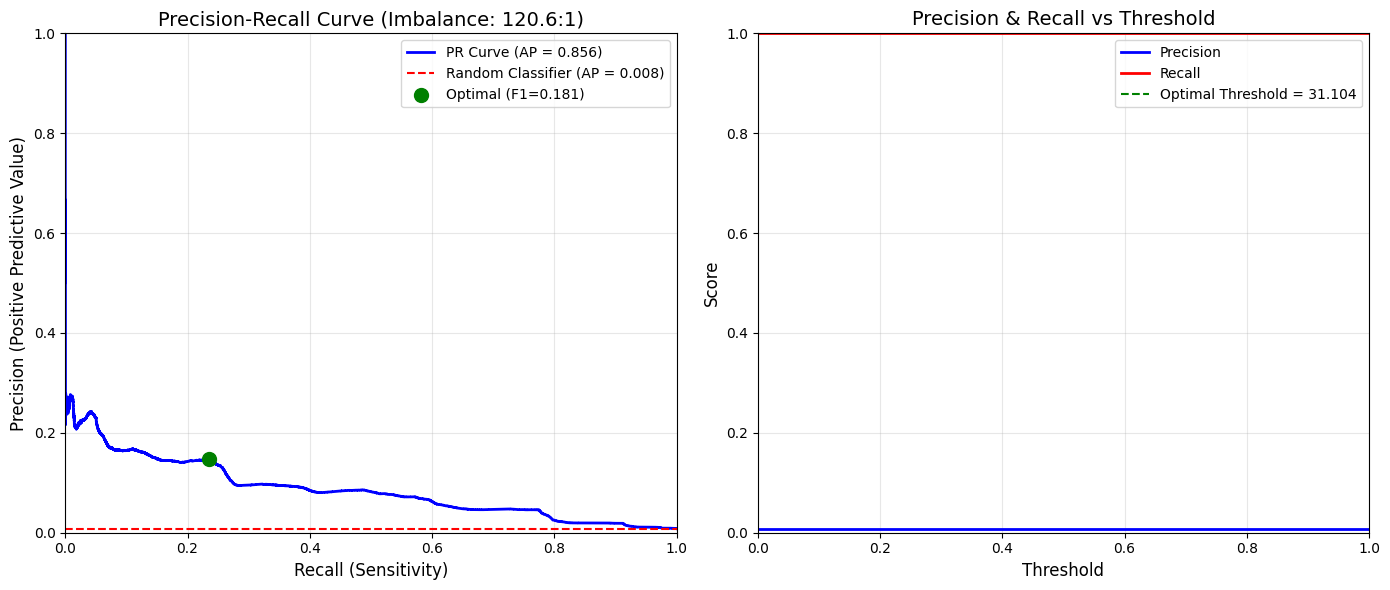

In [24]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_val_top.mean()
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
# Plot 1: Precision-Recall Curve
ax1 = axes[0]
ax1.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {auc_roc:.3f})')
ax1.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier (AP = {baseline:.3f})')
ax1.scatter(optimal_recall, optimal_precision, color='green', s=100,
            zorder=5, label=f'Optimal (F1={optimal_f1:.3f})')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax1.set_title(f'Precision-Recall Curve (Imbalance: {1/baseline:.1f}:1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Plot 2: Precision and Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='Recall')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [25]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:3]

    if true_labels[top3_idx].sum() > 0:
        hits += true_labels[top3_idx].sum()

recall_at_3 = hits / positive_customers

print("Recall@3:", recall_at_3)

Recall@3: 0.7951811381889629


In [26]:
def average_precision_at_k(y_true, y_score, k=3):

    topk_idx = np.argsort(-y_score)[:k]

    y_true_topk = y_true[topk_idx]

    precisions = []
    num_hits = 0

    for i, rel in enumerate(y_true_topk, start=1):

        if rel == 1:
            num_hits += 1
            precisions.append(num_hits / i)

    if len(precisions) == 0:
        return 0.0

    return np.mean(precisions)


n_products = 24
n_customers = len(y_pred) // n_products

ap_scores = []

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]

    # optional: skip customers without positives
    if true_labels.sum() == 0:
        continue

    ap = average_precision_at_k(true_labels, pred_probs, k=3)

    ap_scores.append(ap)

map_at_3 = np.mean(ap_scores)

print("MAP@3:", map_at_3)

MAP@3: 0.6364654786115611


In [27]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:3]

    if true_labels[top3_idx].sum() > 0:
        hits += 1

hit_rate_at_3 = hits / positive_customers

print("HitRate@3:", hit_rate_at_3)

HitRate@3: 0.7465099445038089


In [9]:
import os
y_pred = []
y_val = []
best_best_sgd_path = "/content/drive/My Drive/bank_data/best_best_sgd.pkl"
best_model = joblib.load(best_best_sgd_path)
binary_test_dataset = "/content/drive/My Drive/bank_data/binary_test_dataset/file_1/"
for filepath in os.listdir(binary_test_dataset):
  X_vals, y_vals = generate_dtrain(binary_test_dataset+filepath)
  print(X_vals.isnull().sum().sum())
  X_vals = X_vals.dropna()
  y_preds = best_model.decision_function(X_vals)
  y_pred.extend(y_preds)
  y_val.extend(y_vals)
  del X_vals


0
0
0
24
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [17]:
binary_test_dataset = "/content/drive/My Drive/bank_data/binary_test_dataset/file_1/"
y_val = []
y_pred = []
for filepath in os.listdir(binary_test_dataset):
  X_vals, y_vals = generate_dtrain(binary_test_dataset+filepath)
  X_vals = X_vals.dropna()
  y_pred.extend(best_model.decision_function(X_vals))
  y_val.extend(y_vals)
  del X_vals

In [18]:
y_pred = np.array(y_pred)
y_val = np.array(y_val)

In [19]:
print(len(y_pred))
print(y_val.sum())
n_customer = len(y_pred) / 24
idx_list = []
for i in range(int(n_customer)):
  start = i*24
  end = start+24
  customer_probs = y_pred[start:end]
  top_probs_idx = np.argsort(-customer_probs)[:10]
  top_probs_idx = top_probs_idx + start
  idx_list.extend(top_probs_idx)
y_val_top = y_val[idx_list]
y_pred_top = y_pred[idx_list]

22350768
31002.0


In [20]:
print(len(y_val_top))
print(len(y_pred_top))
print(y_val_top.sum() / y_val.sum())

9312820
9312820
0.5282239855493194


Test data performance:
AUC-ROC: 0.7080
AUC-PR: 0.0184


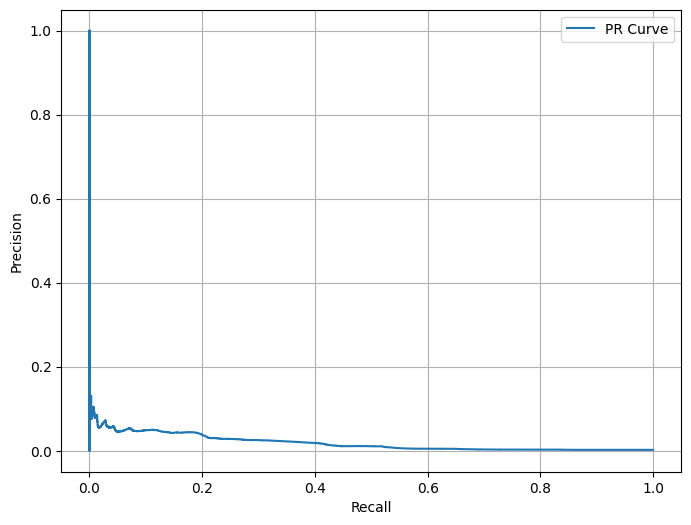

In [48]:
auc_roc = roc_auc_score(y_val_top, y_pred_top)
auc_pr = average_precision_score(y_val_top, y_pred_top)
print(f"Test data performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_val_top, y_pred_top)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='PR Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [49]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

50.37443591460961


/tmp/ipykernel_527/2842373482.py:1: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])


In [50]:
threshold = optimal_threshold
y_pred_top_binary = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top_binary))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   5576105
         1.0       0.00      0.00      0.00     11587

    accuracy                           1.00   5587692
   macro avg       0.50      0.50      0.50   5587692
weighted avg       1.00      1.00      1.00   5587692



In [35]:
threshold = 0.995
y_pred_top_binary = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top_binary))

              precision    recall  f1-score   support

         0.0       1.00      0.00      0.00   2786069
         1.0       0.00      1.00      0.01      7777

    accuracy                           0.00   2793846
   macro avg       0.50      0.50      0.00   2793846
weighted avg       1.00      0.00      0.00   2793846



In [51]:
print(confusion_matrix(y_val_top, y_pred_top_binary))

[[5576094      11]
 [  11587       0]]


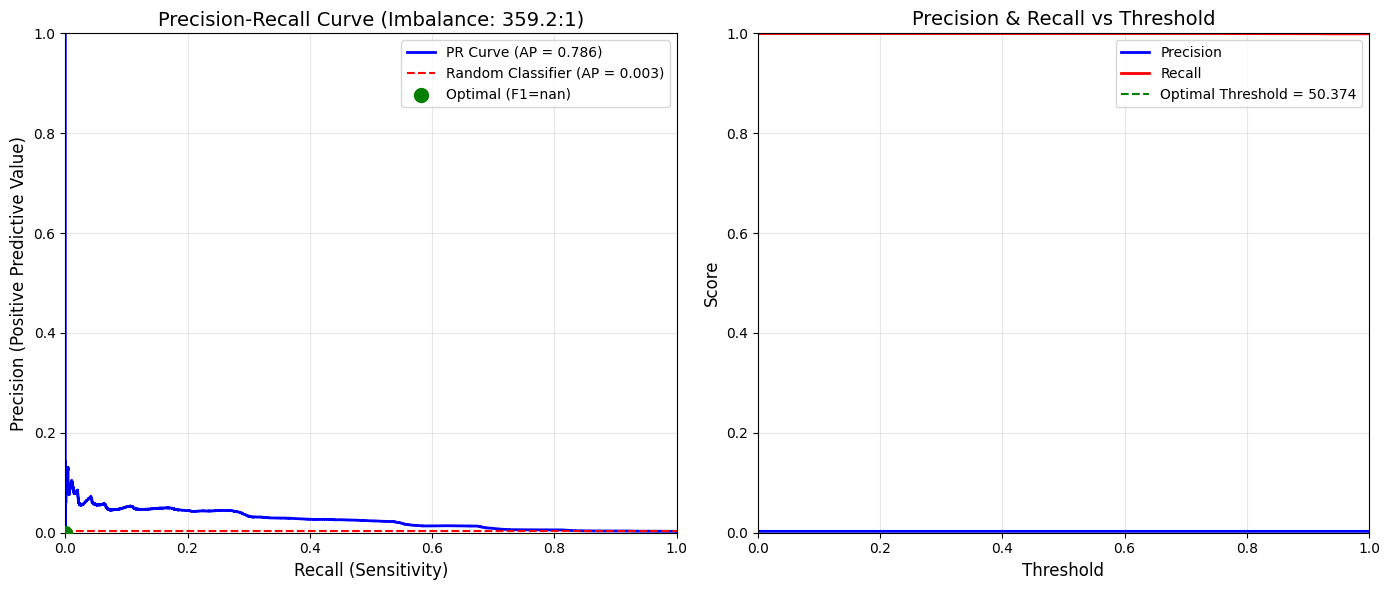

In [37]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_val_top.mean()
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
# Plot 1: Precision-Recall Curve
ax1 = axes[0]
ax1.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {auc_roc:.3f})')
ax1.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier (AP = {baseline:.3f})')
ax1.scatter(optimal_recall, optimal_precision, color='green', s=100,
            zorder=5, label=f'Optimal (F1={optimal_f1:.3f})')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax1.set_title(f'Precision-Recall Curve (Imbalance: {1/baseline:.1f}:1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Plot 2: Precision and Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='Recall')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [25]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:10]

    if true_labels[top3_idx].sum() > 0:
        hits += true_labels[top3_idx].sum()

recall_at_3 = hits / positive_customers

print("Recall@3:", recall_at_3)

Recall@3: 0.5839603466105624


In [24]:
def average_precision_at_k(y_true, y_score, k=3):

    topk_idx = np.argsort(-y_score)[:k]

    y_true_topk = y_true[topk_idx]

    precisions = []
    num_hits = 0

    for i, rel in enumerate(y_true_topk, start=1):

        if rel == 1:
            num_hits += 1
            precisions.append(num_hits / i)

    if len(precisions) == 0:
        return 0.0

    return np.mean(precisions)


n_products = 24
n_customers = len(y_pred) // n_products

ap_scores = []

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]

    # optional: skip customers without positives
    if true_labels.sum() == 0:
        continue

    ap = average_precision_at_k(true_labels, pred_probs, k=10)

    ap_scores.append(ap)

map_at_3 = np.mean(ap_scores)

print("MAP@3:", map_at_3)

MAP@3: 0.2427868596356276


In [23]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:10]

    if true_labels[top3_idx].sum() > 0:
        hits += 1

hit_rate_at_3 = hits / positive_customers

print("HitRate@3:", hit_rate_at_3)

HitRate@3: 0.3937524515921977
